# RPS Classification에 QAT 적용

## Install TensorFlow Model Optimization Toolkit
* 설치 완료 후 반드시 Runtime 재시작!
    * '런타임' > '세션 다시 시작' 메뉴 선택'

In [ ]:
!pip install tensorflow-model-optimization

## 모듈 로딩

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.keras.compat import keras

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.19.0
Matplotlib Version :3.10.0


### g-drive 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Mounted at /content/drive
g-drive mounted.


### RPS 데이터셋 준비

In [ ]:
# files_path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  !unzip -q -o /content/drive/MyDrive/files/RPS_Dataset.zip
  files_path = '/content/RPS_Dataset'
else :
  files_path = '../files/RPS_Dataset'

### 폴더 별로 파일 읽어 데이터화 진행

In [ ]:
%%time
first = True
IMG_SIZE = 64
for ind in range(0, 3, 1) :
    path = files_path + '/' + str(ind) + '/*.*'
    print(path)
    files = glob.glob(path)
    tmpx = np.array([(cv2.resize(cv2.cvtColor(cv2.imread(x, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB), (IMG_SIZE,IMG_SIZE))) for x in files])
    tmpy = np.array([ind] * len(files))

    xtrain, xtest, ytrain, ytest = train_test_split(tmpx, tmpy, test_size=0.2, random_state=123)

    if first == True:
        train_data = xtrain.copy()
        train_labels = ytrain.copy()
        test_data = xtest.copy()
        test_labels = ytest.copy()
        first = False
    else :
        train_data = np.concatenate((train_data, xtrain))
        train_labels = np.concatenate((train_labels, ytrain))
        test_data = np.concatenate((test_data, xtest))
        test_labels = np.concatenate((test_labels, ytest))

/content/RPS_Dataset/0/*.*
/content/RPS_Dataset/1/*.*
/content/RPS_Dataset/2/*.*
CPU times: user 7.22 s, sys: 267 ms, total: 7.49 s
Wall time: 8.15 s


### 데이터 확인

In [ ]:
# Densnet propressing 시 0~1로 변경함 -> 따라서 여기서는 수행 안함
# train_data = train_data / 255.0
# test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(2172, 64, 64, 3)
(2172,)
(545, 64, 64, 3)
(545,)


### ImageDataGenerator 객체 생성

In [ ]:
img_gen_train = tf.keras.preprocessing.image.ImageDataGenerator(
                horizontal_flip=True,         # 좌우 반전 여부 설정
                rotation_range=0.2,          # 회전 범위 설정
                width_shift_range=0.1,       # 좌우로 이동할 범위 설정
                height_shift_range=0.1,      # 상하로 이동할 범위 설정
                brightness_range=(0.1, 0.9), # 밝기 범위 설정
                zoom_range=0.2               # 줌 범위 설정
                )                            # 이외에도 다양한 설정 가능

train_gen = img_gen_train.flow(train_data, train_labels, seed = 1)

### 모델 생성


In [ ]:
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = keras.applications.densenet.preprocess_input(inputs)

base_model = keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_tensor = x
)

for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

x = base_model.output
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(3, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# for layer in base_model.layers:
#     print(layer.trainable)

model.summary()

29084464/29084464 [==============================] - 0s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 tf.math.truediv (TFOpLambd  (None, 64, 64, 3)            0         ['input_1[0][0]']             
 a)                                                                                               
                                                                                                  
 tf.nn.bias_add (TFOpLambda  (None, 64, 64, 3)            0         ['tf.math.truediv[0][0]']     
 )                                                                                                
                             

In [ ]:
# 선택적 양자화 함수
def apply_quantization_to_layer(layer):
    # Dense와 Conv2D 레이어만 양자화
    if isinstance(layer, (keras.layers.Dense, keras.layers.Conv2D)):
        return tfmot.quantization.keras.quantize_annotate_layer(layer)

    return layer

# 모델 복제하면서 선택적 양자화 적용
annotated_model = keras.models.clone_model(
    model,
    clone_function=apply_quantization_to_layer,
)

# 양자화 적용
qat_model = tfmot.quantization.keras.quantize_apply(annotated_model)

In [ ]:
qat_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 tf.math.truediv (TFOpLambd  (None, 64, 64, 3)            0         ['input_1[0][0]']             
 a)                                                                                               
                                                                                                  
 tf.nn.bias_add (TFOpLambda  (None, 64, 64, 3)            0         ['tf.math.truediv[1][0]']     
 )                                                                                                
                                                                                              

### 모델 컴파일

In [ ]:
qat_model.compile(optimizer= keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### 학습 전 상황

In [ ]:
def Make_Result_Plot(suptitle, data, label, y_max):
    size = data.shape[0]//10
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)
    for idx in range(10):
        cnt = idx * size + size//2
        ax_result[idx//5,idx%5].imshow(data[cnt].reshape((IMG_SIZE,IMG_SIZE, 3)))
        ax_result[idx//5,idx%5].set_title("test_data[{}] (label : {} / y : {})".format(cnt, label[cnt], y_max[cnt]))

18/18 [==============================] - 11s 154ms/step


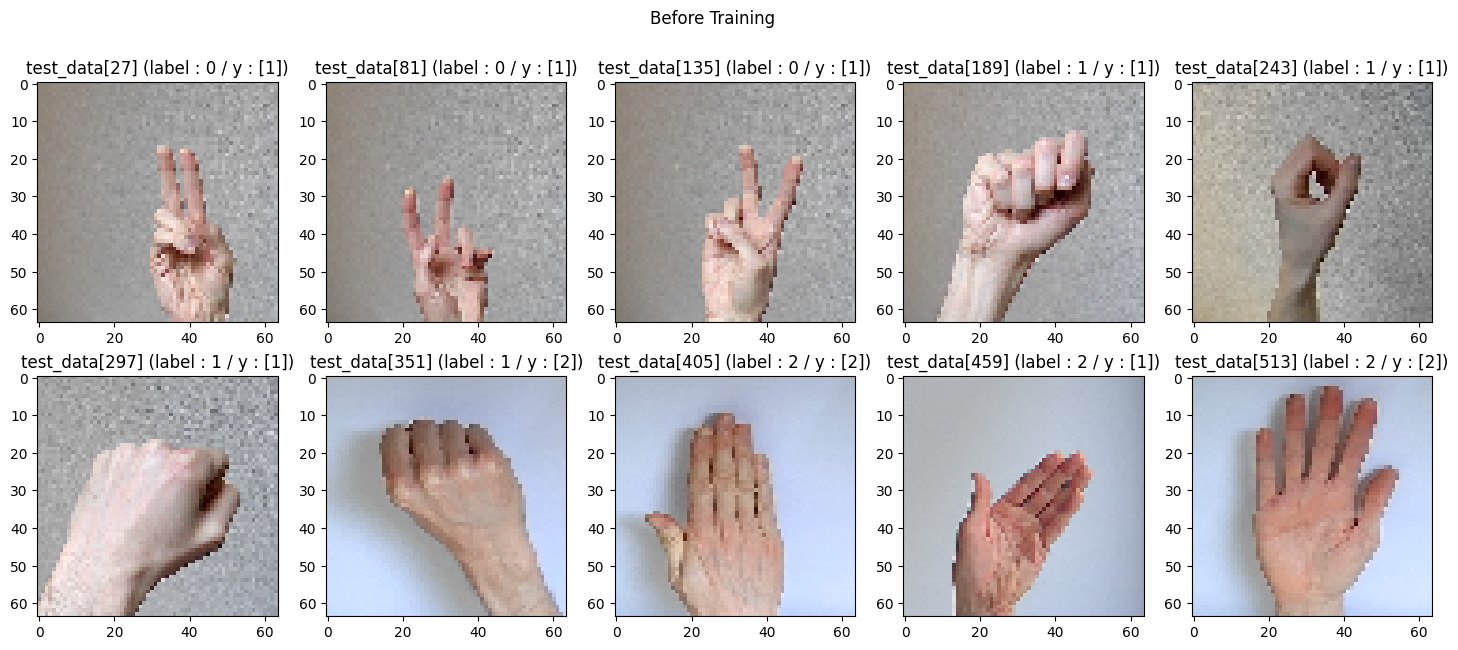

In [ ]:
y_out = qat_model.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("Before Training", test_data, test_labels, y_max)

### 콜백 설정

In [ ]:
savedModelName = 'RPS_PreTrained_DenseNet_Augmentation_QAT.h5'
callbacks = [
    keras.callbacks.ModelCheckpoint(savedModelName,
                                    save_best_only=True)
]

### 모델 학습

In [ ]:
%%time
history = qat_model.fit(train_gen, epochs=10,
                    callbacks=callbacks,
                    validation_data=(test_data, test_labels))

Epoch 1/10
68/68 [==============================] - ETA: 0s - loss: 1.2552 - accuracy: 0.4788

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


68/68 [==============================] - 93s 512ms/step - loss: 1.2552 - accuracy: 0.4788 - val_loss: 0.6366 - val_accuracy: 0.7284
Epoch 2/10
68/68 [==============================] - 27s 391ms/step - loss: 0.6245 - accuracy: 0.7311 - val_loss: 0.2519 - val_accuracy: 0.9229
Epoch 3/10
68/68 [==============================] - 28s 412ms/step - loss: 0.3022 - accuracy: 0.8840 - val_loss: 0.1920 - val_accuracy: 0.9376
Epoch 4/10
68/68 [==============================] - 26s 380ms/step - loss: 0.2080 - accuracy: 0.9199 - val_loss: 0.1081 - val_accuracy: 0.9651
Epoch 5/10
68/68 [==============================] - 26s 380ms/step - loss: 0.1455 - accuracy: 0.9466 - val_loss: 0.0774 - val_accuracy: 0.9780
Epoch 6/10
68/68 [==============================] - 27s 389ms/step - loss: 0.0980 - accuracy: 0.9669 - val_loss: 0.0594 - val_accuracy: 0.9780
Epoch 7/10
68/68 [==============================] - 28s 411ms/step - loss: 0.0933 - accuracy: 0.9678 - val_loss: 0.0472 - val_accuracy: 0.9835
Epoch 8/10

> ### Ploting : Cost/Training Count

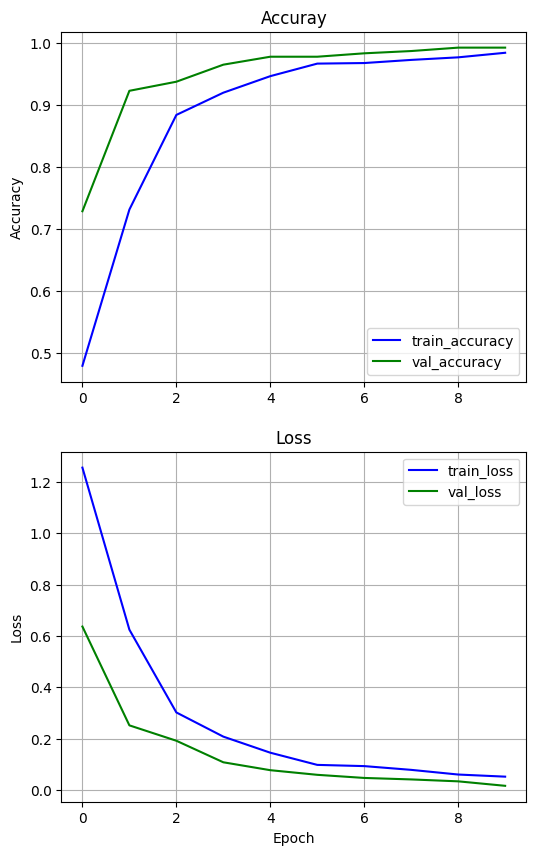

In [ ]:
plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(history.history['val_accuracy'], 'g', label='val_accuracy')
# plt.ylim([0,1])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(history.history['loss'], 'b', label='train_loss')
plt.plot(history.history['val_loss'], 'g', label='val_loss')
# plt.ylim([0,5])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

### best 모델 로딩 및 테스트

In [ ]:
# 사용자 정의 객체(QuantizeWrapperV2 등)를 인식하려면 quantize_scope 필요
from tensorflow_model_optimization.quantization.keras import quantize_scope

try:
    # quantize_scope() 내에서 모델을 로드하여 사용자 정의 객체(QuantizeWrapperV2 등)를 인식시킴
    with quantize_scope():
        model_best = keras.models.load_model(savedModelName)
except ValueError as e:
    print(f"Model load failed: {e}")

18/18 [==============================] - 7s 95ms/step


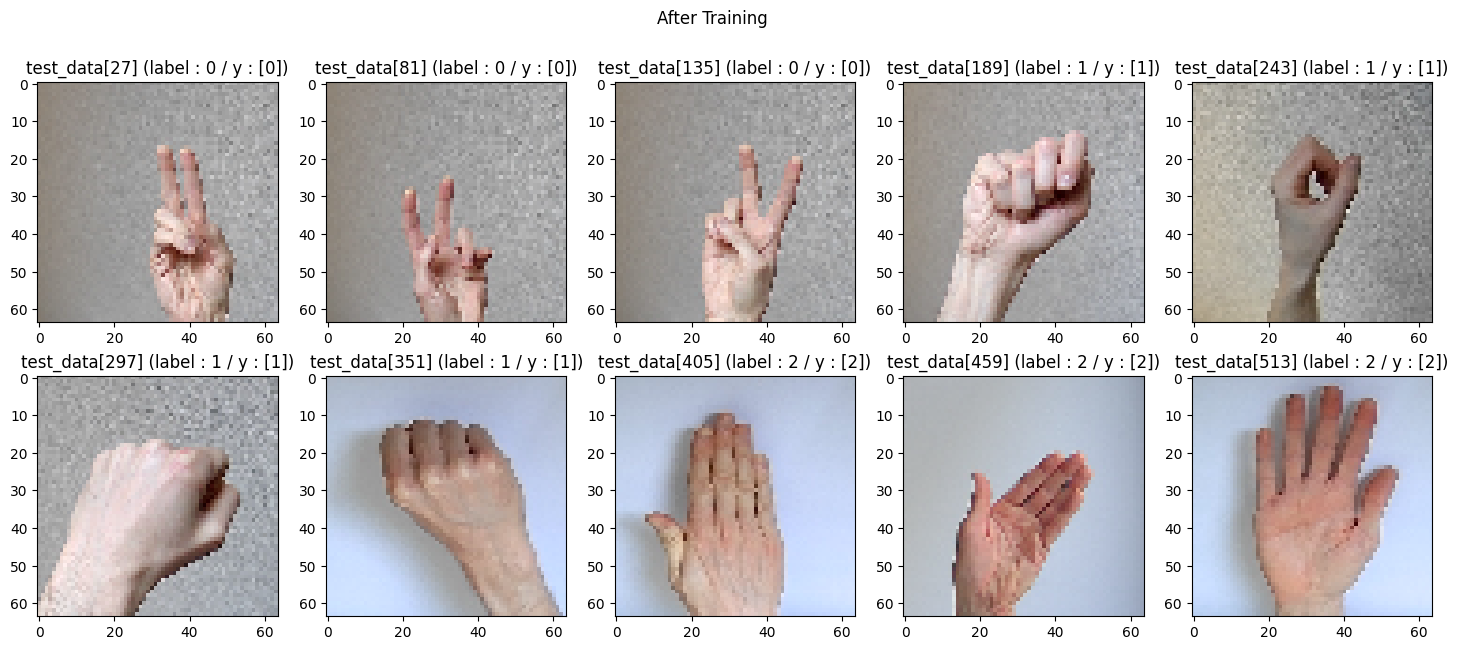

In [ ]:
y_out = model_best.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)

### best 모델 백업

In [ ]:
# save_dir: 다른 경로에 저장하려면, 아래 경로를 수정하세요
if colab :
  save_dir = '/content/drive/MyDrive/files/save/'
else :
  save_dir = '../files/save/'

In [ ]:
# copy saved mode
cpCmd = f'cp {savedModelName} {save_dir}'
print(cpCmd)
!{cpCmd}

cp RPS_PreTrained_DenseNet_Augmentation_QAT.h5 /content/drive/MyDrive/files/save/


### LiteRT 모델로 변환

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_best)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


### LiteRT 모델을 파일로 저장

In [ ]:
tfliteFileName = 'RPS_PreTrained_DenseNet_Augmentation_QAT.tflite'

In [ ]:
open(save_dir + tfliteFileName, 'wb').write(tflite_model)

7703840